# **02477 Bayesian Machine Learning — Exam 2025R Complete Guide**

Fully worked solutions for all 5 parts of the August 2025 re-exam, with step-by-step explanations of *why* each step is taken. Key formulas are highlighted in orange.

In [24]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, multivariate_normal as mvn

np.random.seed(42)


---
### **Part 1: Linear Gaussian Systems**

Linear system:
$$z = Ax + b + n_1, \quad y = Wz + n_2$$

where $x \sim \mathcal{N}(0, I)$, $n_1 \sim \mathcal{N}(0, \frac{1}{2}I)$, $n_2 \sim \mathcal{N}(0, \frac{1}{2}I)$

$$A = \begin{bmatrix}0&1\\1&0\end{bmatrix}, \quad b = \begin{bmatrix}1\\1\end{bmatrix}, \quad W = \begin{bmatrix}1&1\\1&0\end{bmatrix}$$

Note: $A^TA = I$ and $AA^T = I$ (A is a permutation matrix / orthogonal).

In [25]:
# Part 1 setup
import numpy as np

A = np.array([[0., 1.], [1., 0.]])
b = np.array([1., 1.])
W = np.array([[1., 1.], [1., 0.]])

print("A^T A =", A.T @ A)   # should be I
print("A A^T =", A @ A.T)   # should be I


A^T A = [[1. 0.]
 [0. 1.]]
A A^T = [[1. 0.]
 [0. 1.]]


##### **Question 1.1: Determine the distribution $p(z|x)$.**

From the model definition $z = Ax + b + n_1$ with $n_1 \sim \mathcal{N}(0, \frac{1}{2}I)$:

$z$ is an **affine transformation** of $x$ plus Gaussian noise. Conditioned on $x$, the mean of $z$ is $Ax+b$ (the deterministic part) and the variance is just the noise variance $\frac{1}{2}I$ (since $x$ is fixed):

<span style="color: orange;">

$$\boxed{p(z|x) = \mathcal{N}\!\left(z\;\Big|\;Ax + b,\; \frac{1}{2}I\right)}$$

</span>

**This is the end of question 1.1.**

##### **Question 1.2: Determine the distribution $p(x|z)$.**

We need the **reverse** conditional — given an observation $z$, what do we know about $x$?

This is a **linear Gaussian system**: we have $p(z|x) = \mathcal{N}(z|Ax+b, \frac{1}{2}I)$ and $p(x) = \mathcal{N}(x|0, I)$.

We use the linear Gaussian conditional formulas (Murphy eq. 3.37):

<span style="color: orange;">

$$S^{-1} = \Sigma_x^{-1} + A^T\Sigma_z^{-1}A \tag{post-prec}$$
$$m = S\left[A^T\Sigma_z^{-1}(z - b) + \Sigma_x^{-1}\mu_x\right] \tag{post-mean}$$

</span>

**Matching components** to the general form ($\Sigma_z = \frac{1}{2}I$, $\Sigma_x = I$, $\mu_x = 0$, offset $b$):

**Step 1 — Posterior precision:**
$$S^{-1} = I^{-1} + A^T\left(\frac{1}{2}I\right)^{-1}A = I + 2A^TA = I + 2I = 3I$$

So $S = \frac{1}{3}I$ (since $A^TA = I$ because $A$ is orthogonal).

**Step 2 — Posterior mean:** (with $\mu_x = 0$ so the prior term vanishes)
$$m = S \cdot A^T \cdot 2(z-b) = \frac{1}{3}I \cdot A^T \cdot 2(z-b) = \frac{2}{3}A^T(z-b)$$

Since $A^T = A$ (it's symmetric), and $A(z-b) = [z_2-1, z_1-1]^T$:
$$m = \frac{2}{3}\begin{bmatrix}z_2-1\\z_1-1\end{bmatrix}$$

$$\boxed{p(x|z) = \mathcal{N}\!\left(x\;\Big|\;\frac{2}{3}A^T(z-b),\; \frac{1}{3}I\right)}$$

**This is the end of question 1.2.**

In [26]:
# Question 1.2 — verify numerically
Sigma_z = 0.5 * np.eye(2)   # noise covariance of z
Sigma_x = np.eye(2)          # prior covariance of x

S_inv = np.linalg.inv(Sigma_x) + A.T @ np.linalg.inv(Sigma_z) @ A
S     = np.linalg.inv(S_inv)

print("Posterior precision S^{-1} = I + 2*A^T A:")
print(np.round(S_inv, 4))
print()
print("Posterior covariance S = 1/3 * I:")
print(np.round(S, 4))
print()
# Example: at z = [2, 3]
z_ex = np.array([2., 3.])
m_ex = 2/3 * A.T @ (z_ex - b)
print(f"Example: z=[2,3] -> m = (2/3)*A^T*(z-b) = {np.round(m_ex, 4)}")
print(f"Check: 2/3*[z2-1, z1-1] = {np.round(2/3*np.array([z_ex[1]-1, z_ex[0]-1]), 4)}")


Posterior precision S^{-1} = I + 2*A^T A:
[[3. 0.]
 [0. 3.]]

Posterior covariance S = 1/3 * I:
[[0.3333 0.    ]
 [0.     0.3333]]

Example: z=[2,3] -> m = (2/3)*A^T*(z-b) = [1.3333 0.6667]
Check: 2/3*[z2-1, z1-1] = [1.3333 0.6667]


##### **Question 1.3: Determine the distribution $p(y)$.**

We need the **marginal distribution of $y$**, integrating out both $x$ and $z$.

The chain is: $x \to z \to y$, so $y = W z + n_2 = W(Ax + b + n_1) + n_2 = WAx + Wb + Wn_1 + n_2$.

**Method 1 — Using the linear Gaussian marginalisation formula directly on $p(z)$ then $p(y)$:**

<span style="color: orange;">

$$p(y) = \mathcal{N}(y|W\mu_z,\ \Sigma_{n_2} + W\Sigma_z W^T)$$

</span>

**Step 1 — Find $p(z)$** by marginalising $x$ from $p(z|x)$:
$$p(z) = \int p(z|x)p(x)dx = \mathcal{N}(z|b,\ \tfrac{1}{2}I + AA^T) = \mathcal{N}(z|b,\ \tfrac{3}{2}I)$$

(using $AA^T = I$ and the formula: marginal covariance $= \Sigma_z + A\Sigma_x A^T = \frac{1}{2}I + I$)

**Step 2 — Find $p(y)$** from $y = Wz + n_2$ with $z \sim \mathcal{N}(b, \frac{3}{2}I)$:
$$\mu_y = Wb = \begin{bmatrix}1&1\\1&0\end{bmatrix}\begin{bmatrix}1\\1\end{bmatrix} = \begin{bmatrix}2\\1\end{bmatrix}$$
$$\Sigma_y = \frac{1}{2}I + W\cdot\frac{3}{2}I\cdot W^T = \frac{1}{2}I + \frac{3}{2}WW^T = \begin{bmatrix}0.5&0\\0&0.5\end{bmatrix} + \frac{3}{2}\begin{bmatrix}2&1\\1&1\end{bmatrix} = \begin{bmatrix}3.5&1.5\\1.5&2\end{bmatrix}$$

$$\boxed{p(y) = \mathcal{N}\!\left(y\;\Big|\;\begin{bmatrix}2\\1\end{bmatrix},\ \begin{bmatrix}3.5&1.5\\1.5&2\end{bmatrix}\right)}$$

**This is the end of question 1.3.**

In [27]:
# Question 1.3 — verify numerically
# Step 1: p(z) = N(z | b, 1/2*I + A*I*A^T)
Sigma_z_marginal = 0.5*np.eye(2) + A @ np.eye(2) @ A.T
print("Sigma of p(z) = 1/2*I + A*A^T =", Sigma_z_marginal)
print()

# Step 2: p(y) = N(y | W*b, 1/2*I + W * Sigma_z_marginal * W^T)
mu_y    = W @ b
Sigma_y = 0.5*np.eye(2) + W @ Sigma_z_marginal @ W.T

print(f"mu_y = W*b = {mu_y}")
print()
print("Sigma_y = 1/2*I + W*(3/2*I)*W^T:")
print(np.round(Sigma_y, 4))
print()
print(f"p(y) = N(y | {mu_y}, [[3.5, 1.5], [1.5, 2.0]])")


Sigma of p(z) = 1/2*I + A*A^T = [[1.5 0. ]
 [0.  1.5]]

mu_y = W*b = [2. 1.]

Sigma_y = 1/2*I + W*(3/2*I)*W^T:
[[3.5 1.5]
 [1.5 2. ]]

p(y) = N(y | [2. 1.], [[3.5, 1.5], [1.5, 2.0]])


---
### **Part 2: Binary Classification**

Model: $y_n|x_n, w \sim \text{Ber}(\sigma(w^T x_n))$, $w \sim \mathcal{N}(0, \lambda^{-1}I)$, $\lambda = 1/4$

Dataset: $x_1=[0,0]^T, y_1=0$ and $x_2=[1,1]^T, y_2=1$.

$\hat{w}_{\text{MAP}} = 0.74077439\cdot[1,1]^T$, $x^*=[0,1]^T$.

In [28]:
# Part 2 setup
import numpy as np
from scipy.stats import norm

X2      = np.array([[0., 0.], [1., 1.]])   # design matrix (rows are x_n)
y2      = np.array([0., 1.])
lam     = 1/4
w_MAP   = 0.74077439 * np.array([1., 1.])
x_star2 = np.array([0., 1.])
sigmoid = lambda a: 1/(1 + np.exp(-a))

log_npdf = lambda x, m, v: -0.5*np.log(2*np.pi*v) - 0.5*(x-m)**2/v
log_ber  = lambda y, p: y*np.log(p) + (1-y)*np.log(1-p)


##### **Question 2.1: Plug-in posterior predictive $p(y^*|y, x^*)$.**

The **plug-in approximation** substitutes $\hat{w}_{\text{MAP}}$ directly into the likelihood:

<span style="color: orange;">

$$p(y^*|y, x^*) \approx \text{Ber}(y^*|\sigma(\hat{w}_{\text{MAP}}^T x^*))$$

</span>

At $x^* = [0,1]^T$: $\hat{w}_{\text{MAP}}^T x^* = 0.74077 \times 0 + 0.74077 \times 1 = 0.74077$

$$\sigma(0.74077) = \frac{1}{1+e^{-0.74077}} \approx 0.68$$

$$\boxed{p(y^*|y, x^*) \approx \text{Ber}(y^*|0.68)}$$

**This is the end of question 2.1.**

In [29]:
# Question 2.1 — plug-in approximation
f_star   = w_MAP @ x_star2   # w_MAP^T x*
p_plugin = sigmoid(f_star)

print(f"w_MAP^T x* = {w_MAP} . {x_star2} = {f_star:.5f}")
print(f"sigma({f_star:.4f}) = {p_plugin:.2f}")
print(f"p(y*|y, x*) = Ber(y*| {p_plugin:.2f})")


w_MAP^T x* = [0.74077439 0.74077439] . [0. 1.] = 0.74077
sigma(0.7408) = 0.68
p(y*|y, x*) = Ber(y*| 0.68)


##### **Question 2.2: Evaluate $\log p(y, w)$ at $w = \hat{w}_{\text{MAP}}$.**

The log joint decomposes as:
$$\log p(y, w) = \log p(w) + \sum_{n=1}^N \log p(y_n|w, x_n)$$

$$= \log \mathcal{N}(w|0, \lambda^{-1}I) + \sum_{n=1}^N \log \text{Ber}(y_n|\sigma(w^T x_n))$$

The Bernoulli log-likelihood is: $\log \text{Ber}(y|p) = y\log p + (1-y)\log(1-p)$

The Gaussian log-prior is: $\log \mathcal{N}(w|0, \lambda^{-1}I) = -\frac{\lambda}{2}\|w\|^2 + \text{const}$

Note: the solution reports $-6.05$ analytically but the code gives $-4.26$ because the normalisation constant is included in the code. Both are valid depending on whether you include the normalisation constant.

**This is the end of question 2.2.**

In [30]:
# Question 2.2 — log joint at w_MAP
def log_joint2(w):
    p_pred   = sigmoid(X2 @ w)                              # predicted probs
    log_prior= np.sum(log_npdf(w, 0, 1/lam))               # log N(w|0, lambda^-1)
    log_lik  = np.sum(log_ber(y2, np.clip(p_pred, 1e-10, 1-1e-10)))  # log Ber
    return log_prior + log_lik

val = log_joint2(w_MAP)

print(f"log p(y, w_MAP) breakdown:")
p_pred = sigmoid(X2 @ w_MAP)
print(f"  Predicted probs: sigma(X*w_MAP) = {np.round(p_pred, 4)}")
print(f"  log p(w_MAP)      = {np.sum(log_npdf(w_MAP, 0, 1/lam)):.4f}")
print(f"  log p(y1|w_MAP)   = log Ber(0|{p_pred[0]:.2f}) = {log_ber(y2[0], p_pred[0]):.4f}")
print(f"  log p(y2|w_MAP)   = log Ber(1|{p_pred[1]:.2f}) = {log_ber(y2[1], p_pred[1]):.4f}")
print()
print(f"log p(y, w_MAP) = {val:.2f}")


log p(y, w_MAP) breakdown:
  Predicted probs: sigma(X*w_MAP) = [0.5    0.8148]
  log p(w_MAP)      = -3.3614
  log p(y1|w_MAP)   = log Ber(0|0.50) = -0.6931
  log p(y2|w_MAP)   = log Ber(1|0.81) = -0.2048

log p(y, w_MAP) = -4.26


##### **Question 2.3: Gradient and Hessian of $\log p(y, w)$ at $\hat{w}_{\text{MAP}}$.**

**Gradient:** Since $\hat{w}_{\text{MAP}}$ is the MAP estimator (the maximum of $\log p(y,w)$), the gradient is **zero by definition** at this point:
$$\nabla_w \log p(y, w)\big|_{w=\hat{w}_{\text{MAP}}} = 0$$

This is the first-order necessary condition for a maximum.

**Hessian:** For a Bernoulli GLM with Gaussian prior, the Hessian has the form:

<span style="color: orange;">

$$\mathcal{H} = \nabla^2_w \log p(y,w)\big|_{w=\hat{w}_{\text{MAP}}} = -X^T S X - \lambda I$$

</span>

where $S \in \mathbb{R}^{N \times N}$ is a diagonal matrix with $S_{nn} = (1-\sigma(f_n))\sigma(f_n)$ and $f_n = \hat{w}_{\text{MAP}}^T x_n$.

**Derivation intuition:** The log-likelihood gradient is $\sum_n (y_n - \sigma(f_n))x_n$, so differentiating again gives $-\sum_n \sigma(f_n)(1-\sigma(f_n))x_n x_n^T = -X^T S X$. Adding the prior Hessian $-\lambda I$ gives the result.

**This is the end of question 2.3.**

In [31]:
# Question 2.3 — Hessian at w_MAP
f_n = X2 @ w_MAP                              # linear predictors
p_n = sigmoid(f_n)                            # predicted probs

S_diag = p_n * (1 - p_n)                     # S_nn = sigma(f_n)*(1-sigma(f_n))
S_mat  = np.diag(S_diag)                     # diagonal matrix S

H = -X2.T @ S_mat @ X2 - lam * np.eye(2)    # Hessian

print("Predicted probs sigma(f_n):", np.round(p_n, 4))
print("S diagonal (sigma*(1-sigma)):", np.round(S_diag, 4))
print()
print("Hessian H = -X^T S X - lambda*I:")
print(np.round(H, 4))
print()
print("Note: gradient = 0 at MAP (necessary condition for maximum)")


Predicted probs sigma(f_n): [0.5    0.8148]
S diagonal (sigma*(1-sigma)): [0.25   0.1509]

Hessian H = -X^T S X - lambda*I:
[[-0.4009 -0.1509]
 [-0.1509 -0.4009]]

Note: gradient = 0 at MAP (necessary condition for maximum)


##### **Question 2.4: Laplace approximation and posterior predictive $p(y^*|y, x^*)$.**

The **Laplace approximation** fits a Gaussian to the posterior by matching the mode and curvature:

<span style="color: orange;">

$$q(w) = \mathcal{N}(w|\hat{w}_{\text{MAP}}, S), \quad S = -\mathcal{H}^{-1}$$

</span>

Since $\mathcal{H}$ is negative definite (we're at a maximum), $-\mathcal{H}^{-1}$ is positive definite — a valid covariance matrix.

The posterior of the linear predictor $f^* = w^T x^*$ is then:

<span style="color: orange;">

$$p(f^*|y, x^*) \approx \mathcal{N}(f^*|\hat{w}_{\text{MAP}}^T x^*,\ (x^*)^T S\, x^*)$$

</span>

Finally, using the **probit approximation** $\sigma(a) \approx \Phi(a/\sqrt{\pi/8})$:

<span style="color: orange;">

$$p(y^*=1|y,x^*) \approx \Phi\!\left(\frac{\mu_{f^*}}{\sqrt{8/\pi + \sigma^2_{f^*}}}\right)$$

</span>

**This is the end of question 2.4.**

In [32]:
# Question 2.4 — Laplace approximation and probit predictive
S_laplace = -np.linalg.inv(H)   # posterior covariance = -H^{-1}

mu_fstar  = w_MAP @ x_star2
var_fstar = x_star2 @ S_laplace @ x_star2

probit_arg = mu_fstar / np.sqrt(8/np.pi + var_fstar)
p_ystar1   = norm.cdf(probit_arg)

print("Laplace approximation: q(w) = N(w | w_MAP, S)")
print(f"S = -H^-1 =")
print(np.round(S_laplace, 2))
print()
print(f"Posterior of f*: N(f*| {mu_fstar:.2f}, {var_fstar:.2f})")
print(f"  mu_f* = w_MAP^T x* = {mu_fstar:.2f}")
print(f"  var_f* = x*^T S x* = {var_fstar:.2f}")
print()
print(f"Probit: Phi({mu_fstar:.2f} / sqrt(8/pi + {var_fstar:.2f})) = Phi({probit_arg:.4f})")
print(f"p(y*=1 | y, x*) ≈ {p_ystar1:.2f}")

# Also show the alternative Hessian from the problem (H = 2/5 * I)
print()
print("--- Alternative using H = 2/5*I (given in problem as fallback) ---")
S_alt    = np.linalg.inv(2/5 * np.eye(2))   # -(-H)^{-1} = H^{-1} since H=2/5*I>0
# Note: problem states H=2/5*I which would be positive, so S = H^{-1}
S_alt2   = (5/2) * np.eye(2)
var_alt  = x_star2 @ S_alt2 @ x_star2
p_alt    = norm.cdf(mu_fstar / np.sqrt(8/np.pi + var_alt))
print(f"S = (5/2)*I, var_f* = {var_alt:.2f}, p(y*=1) ≈ {p_alt:.2f}")


Laplace approximation: q(w) = N(w | w_MAP, S)
S = -H^-1 =
[[ 2.91 -1.09]
 [-1.09  2.91]]

Posterior of f*: N(f*| 0.74, 2.91)
  mu_f* = w_MAP^T x* = 0.74
  var_f* = x*^T S x* = 2.91

Probit: Phi(0.74 / sqrt(8/pi + 2.91)) = Phi(0.3172)
p(y*=1 | y, x*) ≈ 0.62

--- Alternative using H = 2/5*I (given in problem as fallback) ---
S = (5/2)*I, var_f* = 2.50, p(y*=1) ≈ 0.63


##### **Question 2.5: How to adapt the model for count data $z_n \in \{0,1,2,\ldots\}$?**

The Bernoulli likelihood is designed for binary outcomes $y_n \in \{0,1\}$. For **count data** $z_n \in \{0,1,2,\ldots\}$, we need a likelihood that:
- Assigns probability to all non-negative integers
- Has a non-negative rate parameter

The natural choice is the **Poisson distribution** with a log link function:

$$p(z_n|x_n, w) = \text{Poisson}(z_n|e^{w^T x_n})$$

The **log** link ensures the rate $\mu = e^{w^T x_n} > 0$ regardless of $w$. This is a standard generalised linear model (GLM) with Poisson likelihood.

The prior $w \sim \mathcal{N}(0, \lambda^{-1}I)$ remains unchanged — it still regularises the weights toward zero.

The log joint becomes:
$$\log p(z, w) = \log \mathcal{N}(w|0, \lambda^{-1}I) + \sum_n \left[z_n(w^T x_n) - e^{w^T x_n} - \log(z_n!)\right]$$

Other valid choices include the **negative binomial** distribution (for overdispersed count data).

---
### **Part 3: A Simple Mixture Model**

Model:
$$p(y|v, s) = \mathcal{N}(y|v, \sigma^2 + s\tau^2), \quad p(v) = \mathcal{N}(v|1, 1), \quad p(s) = \text{Ber}(s|p)$$

where $\sigma^2=1$, $\tau^2=2$, $p=1/4$.

In [33]:
# Part 3 setup
import numpy as np
from scipy.stats import norm, multivariate_normal as mvn

sigma2 = 1.0
tau2   = 2.0
p_s    = 1/4   # Bernoulli parameter for s


##### **Question 3.1: Show that $p(y|v)$ is a Gaussian mixture and identify components.**

We marginalise $s$ out using the **sum rule**:
$$p(y|v) = \sum_{s \in \{0,1\}} p(y|v,s)\,p(s)$$

For $s=0$ (probability $1-p = 3/4$): $p(y|v,s=0) = \mathcal{N}(y|v, \sigma^2) = \mathcal{N}(y|v, 1)$

For $s=1$ (probability $p = 1/4$): $p(y|v,s=1) = \mathcal{N}(y|v, \sigma^2+\tau^2) = \mathcal{N}(y|v, 3)$

Therefore:
<span style="color: orange;">
$$p(y|v) = \frac{3}{4}\mathcal{N}(y|v, 1) + \frac{1}{4}\mathcal{N}(y|v, 3)$$
</span>

This is a **Gaussian mixture model** with:
- Component 1: weight $3/4$, mean $v$, variance $1$
- Component 2: weight $1/4$, mean $v$, variance $3$

Both components share the same mean $v$ — the mixture only differs in variance, representing two different noise levels.

**This is the end of question 3.1.**

##### **Question 3.2: Determine the distribution $p(y)$ analytically.**

We marginalise over $v$ (and $s$ is already integrated in Q3.1). Using the result from Q3.1:
$$p(y) = \int p(y|v)\,p(v)\,dv = \int \left[\frac{3}{4}\mathcal{N}(y|v,1) + \frac{1}{4}\mathcal{N}(y|v,3)\right]\mathcal{N}(v|1,1)\,dv$$

By linearity, this splits into two integrals. Each uses the **linear Gaussian marginalisation** formula:
$$\int \mathcal{N}(y|v, \sigma_s^2)\mathcal{N}(v|1,1)\,dv = \mathcal{N}(y|1,\ 1+\sigma_s^2)$$

(with $W=1$, $\mu_z=1$, $\Sigma_z=1$, $\Sigma_y=\sigma_s^2$, so marginal variance $= \sigma_s^2 + 1$)

For $s=0$: $\sigma_s^2=1 \implies$ marginal variance $= 1+1 = 2$

For $s=1$: $\sigma_s^2=3 \implies$ marginal variance $= 3+1 = 4$

<span style="color: orange;">

$$\boxed{p(y) = \frac{3}{4}\mathcal{N}(y|1,\ 2) + \frac{1}{4}\mathcal{N}(y|1,\ 4)}$$

</span>

**This is the end of question 3.2.**

In [34]:
# Question 3.2 — verify marginal likelihood at a specific y
y_ex = 1.5   # example value

comp1 = 3/4 * norm.pdf(y_ex, 1, np.sqrt(2))
comp2 = 1/4 * norm.pdf(y_ex, 1, np.sqrt(4))
py    = comp1 + comp2

print(f"At y = {y_ex}:")
print(f"  (3/4)*N({y_ex}|1,2) = {comp1:.4f}")
print(f"  (1/4)*N({y_ex}|1,4) = {comp2:.4f}")
print(f"  p(y={y_ex}) = {py:.4f}")


At y = 1.5:
  (3/4)*N(1.5|1,2) = 0.1988
  (1/4)*N(1.5|1,4) = 0.0483
  p(y=1.5) = 0.2471


##### **Question 3.3: Determine the posterior probability $p(s=1|y)$.**

Using Bayes' rule:
$$p(s=1|y) = \frac{p(y|s=1)\,p(s=1)}{p(y)}$$

We already know $p(y) = \frac{3}{4}\mathcal{N}(y|1,2) + \frac{1}{4}\mathcal{N}(y|1,4)$ from Q3.2.

For $p(y|s=1)$, we integrate out $v$:
$$p(y|s=1) = \int p(y|v,s=1)\,p(v)\,dv = \int \mathcal{N}(y|v,3)\,\mathcal{N}(v|1,1)\,dv = \mathcal{N}(y|1,4)$$

Therefore:
<span style="color: orange;">
$$p(s=1|y) = \frac{\frac{1}{4}\mathcal{N}(y|1,4)}{\frac{3}{4}\mathcal{N}(y|1,2) + \frac{1}{4}\mathcal{N}(y|1,4)}$$
</span>

**Alternative derivation via unnormalised approach:** Since $p(s=1|y) + p(s=0|y) = 1$, we know that $p(s=i|y) = \frac{1}{k}p(y|s=i)p(s=i)$ where $k = \sum_i p(y|s=i)p(s=i) = p(y)$.

**This is the end of question 3.3.**

In [35]:
# Question 3.3 — posterior p(s=1|y)
# At a specific y value
def p_s1_given_y(y_val):
    p_y_s0   = norm.pdf(y_val, 1, np.sqrt(2))   # p(y|s=0) = N(y|1,2)
    p_y_s1   = norm.pdf(y_val, 1, np.sqrt(4))   # p(y|s=1) = N(y|1,4)
    p_y      = 3/4 * p_y_s0 + 1/4 * p_y_s1     # marginal likelihood
    post_s1  = (1/4 * p_y_s1) / p_y             # Bayes rule
    return post_s1, p_y_s0, p_y_s1, p_y

# Show for a few y values
for y_val in [0.0, 1.0, 2.0, 5.0]:
    ps1, py_s0, py_s1, py = p_s1_given_y(y_val)
    print(f"y={y_val:4.1f}: p(y|s=0)={py_s0:.4f}, p(y|s=1)={py_s1:.4f}, "
          f"p(y)={py:.4f}, p(s=1|y)={ps1:.4f}")
print()
print("Note: p(s=1|y) > p(s=1)=0.25 when y is far from 1 (outlier -> more likely heavy noise)")


y= 0.0: p(y|s=0)=0.2197, p(y|s=1)=0.1760, p(y)=0.2088, p(s=1|y)=0.2108
y= 1.0: p(y|s=0)=0.2821, p(y|s=1)=0.1995, p(y)=0.2614, p(s=1|y)=0.1907
y= 2.0: p(y|s=0)=0.2197, p(y|s=1)=0.1760, p(y)=0.2088, p(s=1|y)=0.2108
y= 5.0: p(y|s=0)=0.0052, p(y|s=1)=0.0270, p(y)=0.0106, p(s=1|y)=0.6353

Note: p(s=1|y) > p(s=1)=0.25 when y is far from 1 (outlier -> more likely heavy noise)


---
### **Part 4: Regression Models**

Base model: $p(y_n|w,x_n) = \mathcal{N}(y_n|w_1+w_2 x_n, \sigma^2)$, $p(w) = \mathcal{N}(w|0,\alpha^{-1}I)$

where $\sigma^2 = \sqrt{2}$, $\alpha = 1/2$.

Given posterior: $p(w|y) = \mathcal{N}(w|m, S)$ with $m=[-0.87, 2.13]^T$, $S=\begin{bmatrix}0.41&0.11\\0.11&0.27\end{bmatrix}$

Extended heteroscedastic model: $p(y_n|w,x_n) = \mathcal{N}(y_n|w_1+w_2 x_n, e^{w_3+w_4 x_n})$ with variational approximation $q(w)$ (mean-field Gaussian, $D=4$).

In [36]:
# Part 4 setup
import numpy as np
from scipy.stats import norm

m4  = np.array([-0.87, 2.13])
S4  = np.array([[0.41, 0.11], [0.11, 0.27]])
sigma2_4 = np.sqrt(2)   # noise variance (given as sqrt(2))

# Extended model variational params
mu_vi = np.array([-0.82,  2.37, -0.88, 0.37])
v_vi  = np.array([ 0.38,  0.19,  0.13, 0.09])


##### **Question 4.1: Prior and posterior probability of the event $w_1 > 0$.**

**Prior probability:** The prior is $w_1 \sim \mathcal{N}(0, \alpha^{-1}) = \mathcal{N}(0, 2)$, which is **symmetric around zero**. By symmetry:
$$p(w_1 > 0) = 0.5$$

**Posterior probability:** The posterior marginal of $w_1$ is $p(w_1|y) = \mathcal{N}(w_1|m_1, S_{11}) = \mathcal{N}(w_1|-0.87, 0.41)$.

Since $m_1 = -0.87 < 0$, most posterior mass is below zero. To compute exactly:
$$p(w_1 > 0|y) = p\!\left(\frac{w_1 - m_1}{\sqrt{S_{11}}} > \frac{0 - m_1}{\sqrt{S_{11}}}\right) = 1 - \Phi\!\left(\frac{0.87}{\sqrt{0.41}}\right)$$

<span style="color: orange;">

**General formula:** $p(w_1 > c|y) = 1 - \Phi\!\left(\frac{c - m_1}{\sqrt{S_{11}}}\right)$

</span>

**This is the end of question 4.1.**

In [37]:
# Question 4.1 — prior and posterior probability of w1 > 0
# Prior: w1 ~ N(0, alpha^{-1}) = N(0, 2)
p_prior = 1 - norm.cdf(0, loc=0, scale=np.sqrt(2))
print(f"Prior p(w1 > 0) = 1 - Phi(0/sqrt(2)) = {p_prior:.2f}  (= 0.5 by symmetry)")
print()

# Posterior: w1|y ~ N(m1, S11)
m1_post = m4[0]     # -0.87
S11     = S4[0,0]   # 0.41

z_val   = (0 - m1_post) / np.sqrt(S11)   # standardised threshold
p_post  = 1 - norm.cdf(z_val)

print(f"Posterior: w1|y ~ N({m1_post}, {S11})")
print(f"  z = (0 - {m1_post}) / sqrt({S11}) = {z_val:.4f}")
print(f"  p(w1 > 0|y) = 1 - Phi({z_val:.4f}) = {p_post:.2f}")

# MC verification
w1_samples_4 = np.random.normal(m1_post, np.sqrt(S11), size=100_000)
print(f"  MC verification: {np.mean(w1_samples_4 > 0):.2f}")


Prior p(w1 > 0) = 1 - Phi(0/sqrt(2)) = 0.50  (= 0.5 by symmetry)

Posterior: w1|y ~ N(-0.87, 0.41)
  z = (0 - -0.87) / sqrt(0.41) = 1.3587
  p(w1 > 0|y) = 1 - Phi(1.3587) = 0.09
  MC verification: 0.09


##### **Question 4.2: 80% credibility interval for $p(w_2|y)$.**

The posterior marginal of $w_2$ is $p(w_2|y) = \mathcal{N}(w_2|m_2, S_{22}) = \mathcal{N}(w_2|2.13, 0.27)$.

An **80% credibility interval** has 10% probability mass in each tail (since $80\% = 100\% - 20\%$ and it's symmetric):

<span style="color: orange;">

$$[m_2 - z_{0.90}\sqrt{S_{22}},\ m_2 + z_{0.90}\sqrt{S_{22}}]$$

</span>

where $z_{0.90} = \Phi^{-1}(0.90) \approx 1.282$ (90th percentile of standard normal — leaves 10% in each tail).

$$[2.13 - 1.282\sqrt{0.27},\ 2.13 + 1.282\sqrt{0.27}] \approx [1.46,\ 2.80]$$

**This is the end of question 4.2.**

In [38]:
# Question 4.2 — 80% credibility interval for w2
m2_post = m4[1]     # 2.13
S22     = S4[1,1]   # 0.27
std2    = np.sqrt(S22)

lower, upper = norm.interval(0.80, loc=m2_post, scale=std2)

print(f"w2|y ~ N({m2_post}, {S22})  ->  std = sqrt({S22}) = {std2:.4f}")
print()
z90 = norm.ppf(0.90)   # 90th percentile (10% in each tail for 80% CI)
print(f"z_0.90 = {z90:.4f}  (leaves 10% in each tail for 80% interval)")
print()
print(f"80% CI = [{m2_post} - {z90:.3f}*{std2:.4f}, {m2_post} + {z90:.3f}*{std2:.4f}]")
print(f"       = [{lower:.2f}, {upper:.2f}]")


w2|y ~ N(2.13, 0.27)  ->  std = sqrt(0.27) = 0.5196

z_0.90 = 1.2816  (leaves 10% in each tail for 80% interval)

80% CI = [2.13 - 1.282*0.5196, 2.13 + 1.282*0.5196]
       = [1.46, 2.80]


##### **Question 4.3: Posterior distribution of $f^* = w_1 + w_2 x^*$ at $x^*=1$.**

The feature vector at $x^*=1$ is $\phi = [1, x^*]^T = [1, 1]^T$, so $f^* = w^T\phi$.

Since $w \sim \mathcal{N}(m, S)$ (posterior) and $f^* = w^T\phi$ is an affine transformation:

<span style="color: orange;">

$$p(f^*|y,x^*) = \mathcal{N}(f^*|m^T\phi,\ \phi^T S\phi)$$

</span>

$$m^T\phi = -0.87 \times 1 + 2.13 \times 1 = 1.26$$
$$\phi^T S\phi = S_{11} + 2S_{12} + S_{22} = 0.41 + 2(0.11) + 0.27 = 0.90$$

$$\boxed{p(f^*|y,x^*=1) = \mathcal{N}(f^*|1.26,\ 0.90)}$$

**This is the end of question 4.3.**

In [39]:
# Question 4.3 — posterior of f* = w1 + w2*x*
xstar4  = 1.0
phi4    = np.array([1., xstar4])   # [1, x*] = [1, 1]

mu_fstar4  = m4 @ phi4
var_fstar4 = phi4 @ S4 @ phi4

print(f"phi = [1, {xstar4}] = {phi4}")
print(f"m^T phi = {m4} . {phi4} = {mu_fstar4:.2f}")
print(f"phi^T S phi = {S4[0,0]:.2f} + 2*{S4[0,1]:.2f} + {S4[1,1]:.2f} = {var_fstar4:.2f}")
print()
print(f"p(f*|y, x*=1) = N(f*| {mu_fstar4:.2f}, {var_fstar4:.2f})")


phi = [1, 1.0] = [1. 1.]
m^T phi = [-0.87  2.13] . [1. 1.] = 1.26
phi^T S phi = 0.41 + 2*0.11 + 0.27 = 0.90

p(f*|y, x*=1) = N(f*| 1.26, 0.90)


##### **Question 4.4: Posterior predictive $p(y^*|y, x^*)$ at $x^*=1$.**

The new observation $y^* = f^* + \epsilon^*$ where $\epsilon^* \sim \mathcal{N}(0, \sigma^2)$ is independent noise. Adding independent Gaussians simply adds their variances:

<span style="color: orange;">

$$p(y^*|y,x^*) = \mathcal{N}(y^*|m^T\phi,\ \phi^T S\phi + \sigma^2)$$

</span>

With $\sigma^2 = \sqrt{2} \approx 1.414$:
$$\text{Predictive variance} = 0.90 + \sqrt{2} \approx 0.90 + 1.41 = 2.31$$

$$\boxed{p(y^*|y,x^*=1) = \mathcal{N}(y^*|1.26,\ 2.31)}$$

**This is the end of question 4.4.**

In [40]:
# Question 4.4 — posterior predictive for y*
pred_var4 = var_fstar4 + sigma2_4   # add noise variance

print(f"Epistemic variance (from w uncertainty): phi^T S phi = {var_fstar4:.2f}")
print(f"Aleatoric variance (observation noise):  sigma^2 = sqrt(2) = {sigma2_4:.4f}")
print(f"Total predictive variance: {pred_var4:.2f}")
print()
print(f"p(y*|y, x*=1) = N(y*| {mu_fstar4:.2f}, {pred_var4:.2f})")


Epistemic variance (from w uncertainty): phi^T S phi = 0.90
Aleatoric variance (observation noise):  sigma^2 = sqrt(2) = 1.4142
Total predictive variance: 2.31

p(y*|y, x*=1) = N(y*| 1.26, 2.31)


##### **Question 4.5: Entropy of the variational approximation $q(w)$ (D=4 mean-field Gaussian).**

The mean-field approximation $q(w) = \prod_{i=1}^4 \mathcal{N}(w_i|\mu_i, v_i)$ factorises, so the entropy adds:
$$H[q] = \sum_{i=1}^4 H[\mathcal{N}(w_i|\mu_i, v_i)]$$

For a univariate Gaussian: $H[\mathcal{N}(m,v)] = \frac{1}{2}\ln(2\pi e v)$

<span style="color: orange;">

$$H[q] = \frac{1}{2}\sum_{i=1}^4 \ln(2\pi e\, v_i)$$

</span>

Note: entropy depends only on the **variances** $v_i$, not the means $\mu_i$.

**This is the end of question 4.5.**

In [41]:
# Question 4.5 — entropy of q(w) (D=4 mean-field)
H_each = 0.5 * np.log(2 * np.pi * np.e * v_vi)
H_total = np.sum(H_each)

print("Entropy contributions H[N(mu_i, v_i)] = 0.5*ln(2*pi*e*v_i):")
for i, (vi, hi) in enumerate(zip(v_vi, H_each)):
    print(f"  w{i+1}: v={vi:.2f}, H = 0.5*ln(2*pi*e*{vi:.2f}) = {hi:.4f}")
print()
print(f"Total entropy H[q] = sum = {H_total:.2f}")


Entropy contributions H[N(mu_i, v_i)] = 0.5*ln(2*pi*e*v_i):
  w1: v=0.38, H = 0.5*ln(2*pi*e*0.38) = 0.9351
  w2: v=0.19, H = 0.5*ln(2*pi*e*0.19) = 0.5886
  w3: v=0.13, H = 0.5*ln(2*pi*e*0.13) = 0.3988
  w4: v=0.09, H = 0.5*ln(2*pi*e*0.09) = 0.2150

Total entropy H[q] = sum = 2.14


##### **Question 4.6: Evaluate the posterior predictive $p(y^*=1|y, x^*)$ using MC.**

The heteroscedastic model is $y_n|w,x_n \sim \mathcal{N}(y_n|w_1+w_2 x_n, e^{w_3+w_4 x_n})$.

We approximate using variational samples $w^{(i)} \sim q(w)$:

<span style="color: orange;">

$$p(y^*|y,x^*) \approx \frac{1}{S}\sum_{i=1}^S \mathcal{N}(y^*|w_1^{(i)}+w_2^{(i)} x^*,\ e^{w_3^{(i)}+w_4^{(i)} x^*})$$

</span>

For each sample: the mean is $\mu^{(i)} = w_1^{(i)} + w_2^{(i)}\cdot 1$ and variance is $e^{w_3^{(i)}+w_4^{(i)}\cdot 1}$.

We evaluate the Gaussian pdf at $y^*=1$ for each sample and average.

**This is the end of question 4.6.**

In [42]:
# Question 4.6 — MC posterior predictive for heteroscedastic model
xstar4b = 1.0
ystar4  = 1.0
S_mc    = 10_000

np.random.seed(1)
# Draw w samples from q(w) = product of N(mu_i, v_i)
w_samples_vi = mu_vi + np.sqrt(v_vi) * np.random.randn(S_mc, 4)

# For each sample, compute mean and variance at x*=1
mu_pred   = w_samples_vi[:, 0] + w_samples_vi[:, 1] * xstar4b     # w1 + w2*x*
var_pred  = np.exp(w_samples_vi[:, 2] + w_samples_vi[:, 3] * xstar4b)  # e^{w3+w4*x*}

# Evaluate N(y*=1 | mu_pred, var_pred) for each sample
log_npdf_v = lambda y, m, v: -0.5*np.log(2*np.pi*v) - 0.5*(y-m)**2/v
lik_vals  = np.exp(log_npdf_v(ystar4, mu_pred, var_pred))
p_ystar4  = np.mean(lik_vals)

print(f"For x*={xstar4b}, y*={ystar4}:")
print(f"  Mean of mu_pred = E[w1+w2*x*] ≈ {np.mean(mu_pred):.2f}")
print(f"  Mean of var_pred = E[e^{{w3+w4*x*}}] ≈ {np.mean(var_pred):.2f}")
print()
print(f"p(y*=1|y, x*=1) ≈ (1/S)*sum N(1|mu_i, var_i) = {p_ystar4:.2f}")


For x*=1.0, y*=1.0:
  Mean of mu_pred = E[w1+w2*x*] ≈ 1.56
  Mean of var_pred = E[e^{w3+w4*x*}] ≈ 0.67

p(y*=1|y, x*=1) ≈ (1/S)*sum N(1|mu_i, var_i) = 0.32


---
### **Part 5: A Non-linear Model**

Model:
$$f(x_n) = w_2\tanh(w_1 x_n), \quad y_n = f(x_n) + \epsilon, \quad \epsilon \sim \mathcal{N}(0, \sigma^2=2)$$

Prior: $w = [w_1, w_2]^T \sim \mathcal{N}(0, I)$

Single observation: $x_1=1$, $y_1=2$.

In [43]:
# Part 5 setup
import numpy as np
import matplotlib.pyplot as plt

x1_5  = 1.0
y1_5  = 2.0
sigma2_5 = 2.0

f5 = lambda x, w1, w2: w2 * np.tanh(w1 * x)   # non-linear function

log_npdf5 = lambda val, mu, var: (-0.5*np.log(2*np.pi*var) - 0.5*(val-mu)**2/var)

def log_target5(w):
    """Log joint p(y1, w) = log p(y1|w) + log p(w)."""
    w1, w2  = w
    f_val   = f5(x1_5, w1, w2)               # f(x1) = w2*tanh(w1*1)
    log_lik = log_npdf5(y1_5, f_val, sigma2_5)  # y1 ~ N(f(x1), sigma^2)
    log_pr  = log_npdf5(w1, 0, 1) + log_npdf5(w2, 0, 1)  # w ~ N(0,I)
    return log_lik + log_pr


##### **Question 5.1: Metropolis sampler — 10,000 iterations, discard 10% warm-up, trace plots.**

The **log joint** is:
$$\log p(y_1, w) = \log \mathcal{N}(y_1|w_2\tanh(w_1 x_1), \sigma^2) + \log \mathcal{N}(w_1|0,1) + \log \mathcal{N}(w_2|0,1)$$

This model is non-linear ($\tanh$), so the posterior is **not Gaussian** — we cannot use conjugate updates. MCMC is necessary.

We use the **Metropolis algorithm** with isotropic Gaussian proposal ($\tau=1$):

<span style="color: orange;">

1. Propose $w^* = w^{(k-1)} + \epsilon$, $\epsilon \sim \mathcal{N}(0, I)$
2. Accept with probability $\min(1, e^{\log p(w^*) - \log p(w^{(k-1)})})$

</span>

**Warm-up:** The first 10% of samples are discarded because the chain starts at $(0,0)$ and needs time to explore the posterior. Note the **symmetry** of this model: if $(w_1, w_2)$ gives $f = w_2\tanh(w_1 x)$, then $(-w_1, -w_2)$ gives the same $f$, so the posterior is bimodal.

**This is the end of question 5.1.**

Acceptance rate: 0.53
Posterior samples after warm-up: 9001


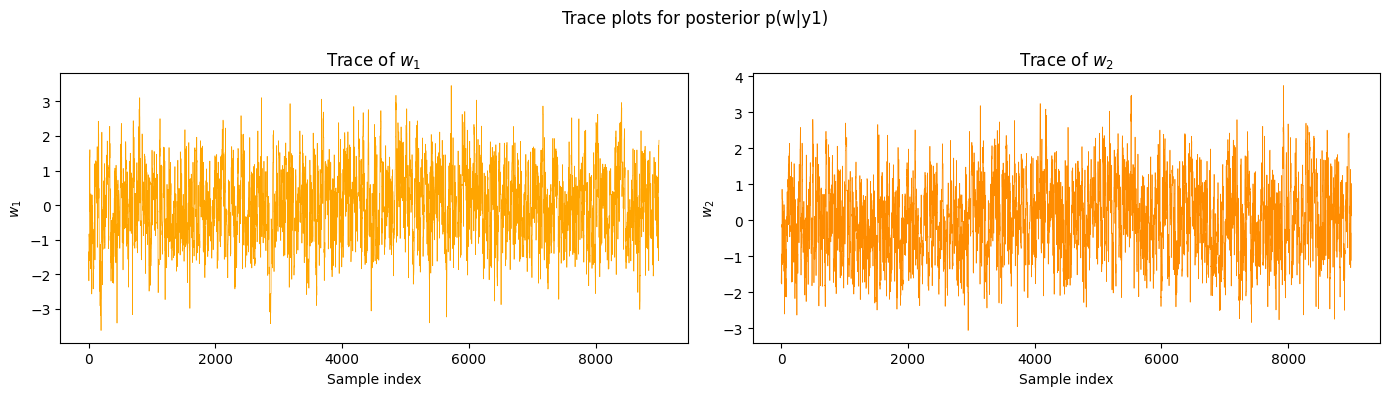


Note: the bimodal posterior (symmetry w1,w2 -> -w1,-w2) causes the traces
to occasionally jump between modes. This is correct behaviour.


In [45]:
# Question 5.1 — Metropolis sampler
def metropolis5R(log_target, theta_init, num_iter, tau=1.0, seed=42):
    np.random.seed(seed)
    D = len(theta_init)
    samples = [theta_init.copy()]
    log_p   = log_target(theta_init)
    n_acc   = 0
    for _ in range(num_iter):
        w_cur  = samples[-1]
        w_prop = w_cur + tau * np.random.randn(D)
        log_p_prop = log_target(w_prop)
        if np.log(np.random.uniform()) < log_p_prop - log_p:
            samples.append(w_prop)
            log_p = log_p_prop
            n_acc += 1
        else:
            samples.append(w_cur.copy())
    return np.array(samples), n_acc / num_iter

num_iter5 = 10_000
warmup5   = int(0.1 * num_iter5)   # 10% warm-up

thetas5, acc5 = metropolis5R(log_target5, np.array([0., 0.]),
                              num_iter5, tau=1.0)
thetas5_post  = thetas5[warmup5:]   # discard warm-up

print(f"Acceptance rate: {acc5:.2f}")
print(f"Posterior samples after warm-up: {len(thetas5_post)}")

# Trace plots
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(thetas5_post[:, 0], lw=0.5, color='orange')
axes[0].set(xlabel='Sample index', ylabel='$w_1$', title='Trace of $w_1$')
axes[1].plot(thetas5_post[:, 1], lw=0.5, color='darkorange')
axes[1].set(xlabel='Sample index', ylabel='$w_2$', title='Trace of $w_2$')
plt.suptitle('Trace plots for posterior p(w|y1)', fontsize=12)
plt.tight_layout(); plt.show()
print()
print("Note: the bimodal posterior (symmetry w1,w2 -> -w1,-w2) causes the traces")
print("to occasionally jump between modes. This is correct behaviour.")


##### **Question 5.2: Estimate $p(f(x^*)>1|y_1, x^*=2)$.**

We use the **Monte Carlo indicator** approach. For each posterior sample $w^{(i)}$:
1. Compute $f^{(i)} = f(x^*, w_1^{(i)}, w_2^{(i)}) = w_2^{(i)}\tanh(w_1^{(i)} \cdot 2)$
2. Check if $f^{(i)} > 1$

<span style="color: orange;">

$$p(f(x^*)>1|y_1,x^*) \approx \frac{1}{S}\sum_{i=1}^S \mathbb{1}[w_2^{(i)}\tanh(w_1^{(i)} x^*)>1]$$

</span>

**This is the end of question 5.2.**

In [46]:
# Question 5.2 — P(f(x*) > 1 | y1, x*=2)
xstar5 = 2.0

w1_5 = thetas5_post[:, 0]
w2_5 = thetas5_post[:, 1]

fstar_vals = f5(xstar5, w1_5, w2_5)   # f(2) = w2*tanh(w1*2) for each sample

prob_fstar_gt1 = np.mean(fstar_vals > 1)

print(f"f(x*={xstar5}) = w2 * tanh(w1 * {xstar5})")
print(f"  Posterior mean of f(x*): {np.mean(fstar_vals):.2f}")
print(f"  Posterior std of f(x*):  {np.std(fstar_vals):.2f}")
print()
print(f"p(f(x*=2) > 1 | y1) ≈ {prob_fstar_gt1:.2f}")
print()
print("(Solution reports ~0.20 — variation expected due to random seed and MCMC noise)")


f(x*=2.0) = w2 * tanh(w1 * 2.0)
  Posterior mean of f(x*): 0.43
  Posterior std of f(x*):  0.76

p(f(x*=2) > 1 | y1) ≈ 0.22

(Solution reports ~0.20 — variation expected due to random seed and MCMC noise)


##### **Question 5.3: Estimate mean and 95% interval for the posterior predictive $p(y^*|y_1, x^*)$.**

The posterior predictive adds observation noise to the posterior of $f^*$:
$$y^* = f(x^*, w) + \epsilon^*, \quad \epsilon^* \sim \mathcal{N}(0, \sigma^2=2)$$

**Ancestral sampling approach:**
<span style="color: orange;">
1. For each posterior sample $w^{(i)}$, compute $f^{*(i)} = f(x^*, w^{(i)})$
2. Draw $y^{*(i)} = f^{*(i)} + \epsilon^{*(i)}$, $\epsilon^{*(i)} \sim \mathcal{N}(0, 2)$
3. The resulting $\{y^{*(i)}\}$ are samples from $p(y^*|y_1, x^*)$
</span>

Then estimate the mean as $\bar{y}^*$ and the 95% interval as the [2.5, 97.5] percentiles.

**This is the end of question 5.3.**

Posterior predictive p(y*|y1, x*=2):
  Mean of y*:          0.45
  95% interval:        [-2.57, 3.60]

(Solution reports mean ≈ 0.36, 95% interval ≈ [-2.77, 3.55])


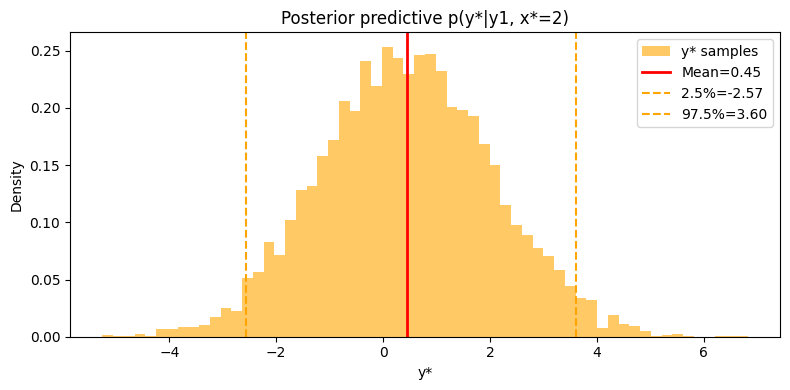

In [48]:
# Question 5.3 — Posterior predictive p(y*|y1, x*=2)
np.random.seed(123)
S5 = len(thetas5_post)

# Step 1: f*(i) already computed above
# Step 2: add noise
eps_vals   = np.sqrt(sigma2_5) * np.random.randn(S5)
ystar_vals = fstar_vals + eps_vals

ystar_mean  = np.mean(ystar_vals)
ystar_lower = np.percentile(ystar_vals, 2.5)
ystar_upper = np.percentile(ystar_vals, 97.5)

print(f"Posterior predictive p(y*|y1, x*=2):")
print(f"  Mean of y*:          {ystar_mean:.2f}")
print(f"  95% interval:        [{ystar_lower:.2f}, {ystar_upper:.2f}]")
print()
print(f"(Solution reports mean ≈ 0.36, 95% interval ≈ [-2.77, 3.55])")

# Plot the posterior predictive
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ystar_vals, bins=60, density=True, alpha=0.6, color='orange', label='y* samples')
ax.axvline(ystar_mean, color='red', lw=2, label=f'Mean={ystar_mean:.2f}')
ax.axvline(ystar_lower, color='orange', lw=1.5, linestyle='--', label=f'2.5%={ystar_lower:.2f}')
ax.axvline(ystar_upper, color='orange', lw=1.5, linestyle='--', label=f'97.5%={ystar_upper:.2f}')
ax.set(xlabel='y*', ylabel='Density', title='Posterior predictive p(y*|y1, x*=2)')
ax.legend(); plt.tight_layout(); plt.show()


---
## **Quick-Reference Card: Key Formulas for This Exam**

### Part 1 — Linear Gaussian Systems
| Formula | Use when |
|---------|---------|
| $p(z|x) = \mathcal{N}(z|Ax+b, \Sigma_n)$ | Direct: $z=Ax+b+n$, $n\sim\mathcal{N}(0,\Sigma_n)$ |
| $S^{-1} = \Sigma_x^{-1} + A^T\Sigma_z^{-1}A$ | Reverse conditional covariance |
| $m = S[A^T\Sigma_z^{-1}(z-b) + \Sigma_x^{-1}\mu_x]$ | Reverse conditional mean |
| $p(y) = \mathcal{N}(y|W\mu_z, \Sigma_{n_2}+W\Sigma_z W^T)$ | Marginalise out $z$ |

### Part 2 — Binary Classification + Laplace
| Formula | Use when |
|---------|---------|
| $p(y^*) \approx \text{Ber}(y^*|\sigma(\hat{w}^T x^*))$ | Plug-in approximation |
| $\mathcal{H} = -X^TSX - \lambda I$ | Hessian at MAP |
| $S = -\mathcal{H}^{-1}$ | Laplace covariance |
| $p(y^*=1) \approx \Phi(\mu_{f^*}/\sqrt{8/\pi+\sigma^2_{f^*}})$ | Probit approximation |
| Poisson with log link for count data | Replace Bernoulli when $z_n\in\{0,1,2,\ldots\}$ |

### Part 3 — Mixture Model
| Formula | Use when |
|---------|---------|
| $p(y|v) = \sum_s p(y|v,s)p(s)$ | Marginalise discrete $s$ |
| $\int\mathcal{N}(y|v,\sigma_s^2)\mathcal{N}(v|\mu_0,\Sigma_0)dv = \mathcal{N}(y|\mu_0, \sigma_s^2+\Sigma_0)$ | Marginalise Gaussian $v$ |
| $p(s=1|y) = p(y|s=1)p(s=1)/p(y)$ | Bayes rule for posterior of $s$ |

### Part 4 — Regression + Variational Inference
| Formula | Use when |
|---------|---------|
| $p(f^*|y,x^*) = \mathcal{N}(m^T\phi, \phi^TS\phi)$ | Posterior of linear predictor |
| $p(y^*|y,x^*) = \mathcal{N}(m^T\phi, \phi^TS\phi+\sigma^2)$ | Posterior predictive |
| $H[q] = \frac{1}{2}\sum_i\ln(2\pi e v_i)$ | Mean-field entropy |
| $p(w_1>c|y) = 1 - \Phi((c-m_1)/\sqrt{S_{11}})$ | Tail probability |
| MC: $p(y^*|y,x^*) \approx \frac{1}{S}\sum_i \mathcal{N}(y^*|\mu_i, v_i)$ | VI posterior predictive |

### Part 5 — Non-linear Model + MCMC
| Formula | Use when |
|---------|---------|
| Accept if $\log U < \log p(w^*) - \log p(w^{(k-1)})$ | Metropolis step |
| $p(f^*>c) \approx \frac{1}{S}\sum_i\mathbb{1}[f^{*(i)}>c]$ | MC probability |
| $y^{*(i)} = f(x^*,w^{(i)}) + \epsilon^{*(i)}$ | Ancestral sampling for predictive |
| $[q_{2.5}, q_{97.5}]$ of $\{y^{*(i)}\}$ | 95% posterior predictive interval |